# 3. Gas dynamics in two dimensions: multidimensional finite volumes and curvilinear grids

The one-dimensional building blocks — reconstruction, Riemann solvers, Runge–Kutta integration —
carry over to two dimensions almost unchanged. What is new is (i) how the one-dimensional pieces are
combined, and what this means for accuracy and stability, (ii) genuinely multidimensional physics such
as shear and buoyancy instabilities, and (iii) curvilinear grids, on which most astrophysical problems
are naturally posed. This notebook covers

1. the multidimensional finite-volume update and the CFL condition;
2. the accuracy of the scheme on a smooth solution, the isentropic vortex;
3. a cylindrical explosion on a Cartesian grid, compared with a one-dimensional radial solution;
4. Kelvin–Helmholtz and Rayleigh–Taylor instabilities, and the Gresho vortex;
5. cylindrical, polar, and spherical coordinates: geometric source terms, the coordinate axis, and two
   tests.

It builds on the notebooks on linear advection and on one-dimensional gas dynamics.

In [1]:
import os, sys, io, contextlib
sys.path.insert(0, os.path.abspath('..'))          # the Piastra root directory

import numpy as np
import matplotlib.pyplot as plt

from src.parameters import Parameters
from src.grid.grid_setup import Grid
from src.sim_state import SimState
from src.misc.helpers import initial_model
from src.models.HD.HD_riemann_exact import exact_riemann_solution
from main import SOLVER_DISPATCH


def setup(problem, N1, N2, init=None, **options):
    '''Parameters, grid, state, EOS and solver for a hydrodynamics problem of the catalogue.
    `init(grid, state, par, eos)`, if given, modifies the set-up before the solver is built.'''
    with contextlib.redirect_stdout(io.StringIO()):
        par = Parameters(mode="HD", problem=problem, Nx1=N1, Nx2=N2, **options)
        grid = Grid(par.Nx1, par.Nx2, par.Ngc)
        state = SimState(grid, par)
        grid, state, par, eos = initial_model(grid, state, par)
        if init is not None:
            init(grid, state, par, eos)
        solver = SOLVER_DISPATCH["HD"](grid, state, eos, par)
    return grid, state, par, eos, solver


def evolve(solver, par, t_end=None):
    '''Advance the solution to t_end (default: the final time of the problem).'''
    if t_end is not None:
        par.timefin = t_end
    with contextlib.redirect_stdout(io.StringIO()):
        while par.timenow < par.timefin - 1e-12:
            state = solver.step_RK()
    return state


def interior(grid, array):
    '''Interior (non-ghost) cells of a 2D array.'''
    g = grid.Ngc
    return array[g:-g, g:-g].copy()


def show(grid, field, ax, title='', **kwargs):
    '''Colour map of an interior field on a Cartesian grid.'''
    x1, x2 = interior(grid, grid.cx1), interior(grid, grid.cx2)
    im = ax.pcolormesh(x1, x2, field, shading='auto', **kwargs)
    ax.set_aspect('equal'); ax.set_title(title)
    return im

## 1. The multidimensional finite-volume update

For a cell of area $\Delta x\,\Delta y$ the integral form of the conservation law gives

$$\frac{d\bar U_{ij}}{dt} = -\frac{F_{i+1/2,j} - F_{i-1/2,j}}{\Delta x}
                           - \frac{G_{i,j+1/2} - G_{i,j-1/2}}{\Delta y},$$

where $F$ and $G$ are the fluxes through the faces normal to $x$ and $y$, **averaged over the face**.
Piastra evaluates this right-hand side in one piece — reconstruction and Riemann problems in $x$, then
in $y$, both from the same state — and advances it with a Runge–Kutta method (an *unsplit*
method-of-lines scheme). The alternative, *dimensional splitting*, applies one-dimensional updates in
$x$ and $y$ in turn; it is simpler to write but needs care with the order of the sweeps.

Two consequences follow from this construction.

* **Stability.** Waves cross a cell in both directions within one step, so the CFL condition becomes
  $$\Delta t = C \Big/ \max_{ij}\left[\frac{|u| + c}{\Delta x} + \frac{|v| + c}{\Delta y}\right],$$
  which is how Piastra computes it: for $\Delta x = \Delta y$ the time step is about half the
  one-dimensional one.
* **Accuracy.** The Riemann problem gives the flux at one point of each face, its centre. Replacing
  the face average by the midpoint value is a second-order quadrature. Whatever the order of the
  reconstruction, this scheme is therefore at most second-order accurate for smooth two-dimensional
  flows; high-order reconstructions reduce the error constant but not the order.

We check the second statement on an exact smooth solution of the Euler equations.

## 2. Accuracy: the advected isentropic vortex

The isentropic vortex (Yee et al. 2000) is a steady, smooth vortex in a uniform flow; it is simply
carried with the flow. On the periodic domain $[-5, 5]^2$ with background $\rho = p = 1$ and velocity
$(1, 1)$, the perturbations are

$$\delta u = -\frac{\beta}{2\pi}\, e^{(1 - r^2)/2}\, y, \quad
  \delta v = \frac{\beta}{2\pi}\, e^{(1 - r^2)/2}\, x, \quad
  T = 1 - \frac{(\gamma - 1)\beta^2}{8\gamma\pi^2}\, e^{1 - r^2}, \quad
  \rho = T^{1/(\gamma-1)}, \quad p = \rho T,$$

with $\beta = 5$ and $\gamma = 1.4$. We advance to $t = 2$, when the vortex has moved by $(2, 2)$.
With $N$ a multiple of 5 this shift is an integer number of cells, so the exact solution is the
initial array shifted by `np.roll` — independently of how the initial data were sampled on the grid.
The catalogue has no such problem, so we build it from the grid of the Gresho vortex (which uses
$\gamma = 1.4$):

PLM   L1 errors 7.61e-03  1.85e-03  3.87e-04   orders 2.04  2.25
WENO  L1 errors 3.57e-03  6.49e-04  1.04e-04   orders 2.46  2.64
MP5   L1 errors 1.17e-03  2.82e-04  7.29e-05   orders 2.05  1.95


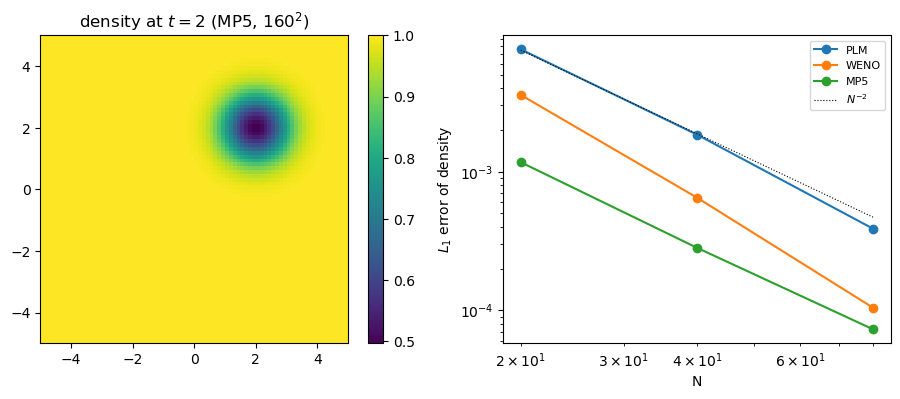

In [3]:
def isentropic_vortex(grid, state, par, eos, beta=5.0):
    grid.CartesianGrid(-5.0, 5.0, -5.0, 5.0)
    x, y = grid.cx1, grid.cx2
    g = eos.GAMMA
    bump = np.exp(0.5 * (1.0 - x**2 - y**2))
    T = 1.0 - (g - 1.0) * beta**2 / (8.0 * g * np.pi**2) * bump**2
    state.dens[:, :] = T**(1.0 / (g - 1.0))
    state.pres[:, :] = state.dens * T
    state.vel1[:, :] = 1.0 - beta / (2.0 * np.pi) * bump * y
    state.vel2[:, :] = 1.0 + beta / (2.0 * np.pi) * bump * x
    state.vel3[:, :] = 0.0
    par.BC[:] = 'peri'
    par.timenow = 0.0; par.timefin = 2.0

Ns = [20, 40, 80]
errors = {}
for rec in ['PLM', 'WENO', 'MP5']:
    errors[rec] = []
    for N in Ns:
        grid, state, par, eos, solver = setup("gresho2D", N, N, init=isentropic_vortex,
                                               rec_type=rec, RK_order='RK3', solver_type='HLLC', CFL=0.4)
        rho0 = interior(grid, state.dens)
        state = evolve(solver, par)
        exact = np.roll(rho0, (N // 5, N // 5), axis=(0, 1))
        errors[rec].append(np.mean(np.abs(interior(grid, state.dens) - exact)))
    e = errors[rec]
    print(f"{rec:5s} L1 errors", "  ".join(f"{v:.2e}" for v in e),
          "  orders", "  ".join(f"{np.log2(e[i] / e[i + 1]):.2f}" for i in range(len(e) - 1)))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
im = show(grid, interior(grid, state.dens), axes[0], r'density at $t = 2$ (MP5, $80^2$)', cmap='viridis')
plt.colorbar(im, ax=axes[0])
for rec in errors:
    axes[1].loglog(Ns, errors[rec], 'o-', label=rec)
Ns_ = np.array(Ns, float)
axes[1].loglog(Ns_, 3.0 * Ns_**-2.0, 'k:', lw=0.8, label=r'$N^{-2}$')
axes[1].set_xlabel('N'); axes[1].set_ylabel(r'$L_1$ error of density'); axes[1].legend(fontsize=8)
plt.show()

The high-order reconstructions reduce the error considerably, but the observed order of all of them
tends to two: the midpoint approximation of the face-averaged flux limits the scheme, not the
reconstruction. Codes that reach higher orders in several dimensions evaluate the flux at several
Gauss points per face, or convert between point values and cell averages with high-order corrections;
both are natural extensions of Piastra.

## 3. A cylindrical explosion on a Cartesian grid

The problem `sod2Dcart` is the Sod problem with the high-pressure gas inside the circle $r < 0.5$,
computed in one quadrant with reflecting walls on the axes. The exact solution is cylindrically
symmetric, so it can be compared with a one-dimensional radial computation of the kind used in the
previous notebook, on a fine radial grid:

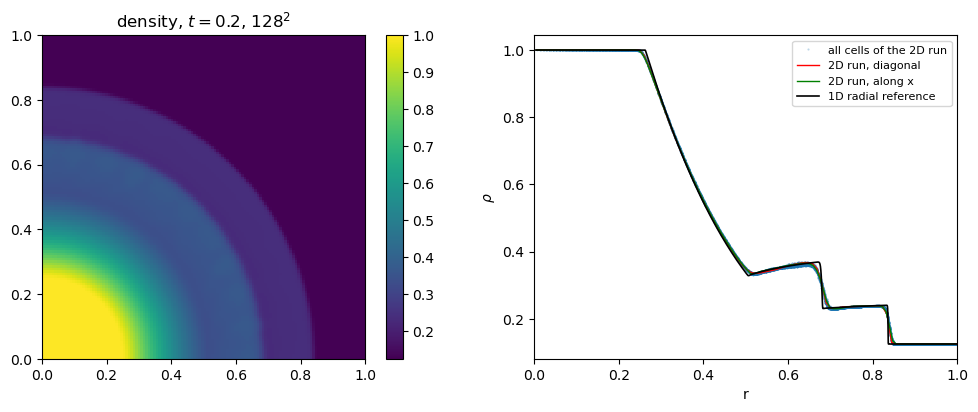

In [4]:
def radial_reference(N=2000):
    '''1D cylindrically symmetric Sod problem on [0, 1] (radial grid, one cell in z).'''
    def cylinder(grid, state, par, eos):
        grid.CylindricalGrid(0.0, 1.0, 0.0, 1.0)
        inner = grid.cx1 < 0.5
        state.dens[:, :] = np.where(inner, 1.0, 0.125)
        state.pres[:, :] = np.where(inner, 1.0, 0.1)
        state.vel1[:, :] = 0.0
        par.BC[:] = 'wall'
    grid, state, par, eos, solver = setup("sod1Dcart", N, 1, init=cylinder,
                                           rec_type='PLM', RK_order='RK2', solver_type='HLLC')
    state = evolve(solver, par, t_end=0.2)
    g = grid.Ngc
    return grid.cx1[g:-g, g], state.dens[g:-g, g]

r_ref, rho_ref = radial_reference()

grid, state, par, eos, solver = setup("sod2Dcart", 128, 128, rec_type='PLM', RK_order='RK2', solver_type='HLLC')
state = evolve(solver, par, t_end=0.2)
rho = interior(grid, state.dens)
r = np.sqrt(interior(grid, grid.cx1)**2 + interior(grid, grid.cx2)**2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
im = show(grid, rho, axes[0], r'density, $t = 0.2$, $128^2$', cmap='viridis')
plt.colorbar(im, ax=axes[0])
axes[1].plot(r.ravel(), rho.ravel(), '.', ms=1, alpha=0.3, label='all cells of the 2D run')
axes[1].plot(np.diag(r), np.diag(rho), 'r-', lw=1, label='2D run, diagonal')
axes[1].plot(r[:, 0], rho[:, 0], 'g-', lw=1, label='2D run, along x')
axes[1].plot(r_ref, rho_ref, 'k-', lw=1.2, label='1D radial reference')
axes[1].set_xlim(0, 1); axes[1].set_xlabel('r'); axes[1].set_ylabel(r'$\rho$'); axes[1].legend(fontsize=8)
plt.show()

The two-dimensional solution follows the radial reference closely, and the spread of the cloud of
points measures how far the scheme is from exact cylindrical symmetry. The cuts along the axis and
along the diagonal differ most at the contact, the least robust wave: on a Cartesian grid a circular
front is resolved differently in different directions, a **grid imprint** that decreases with
resolution. In problems that are unstable at such fronts — for example, Rayleigh–Taylor-unstable
contacts in supernova remnants — the imprint can seed spurious structure along the grid axes.

## 4. Instabilities and dissipation

**Kelvin–Helmholtz instability.** Two layers in relative motion are unstable to perturbations of all
wavelengths; the seeded mode rolls up into vortices. The problem `KHI2D` has a velocity shear between
a dense central layer and the surrounding gas. The instability develops at the contact discontinuities
between the layers, which is exactly where HLL and HLLC differ:

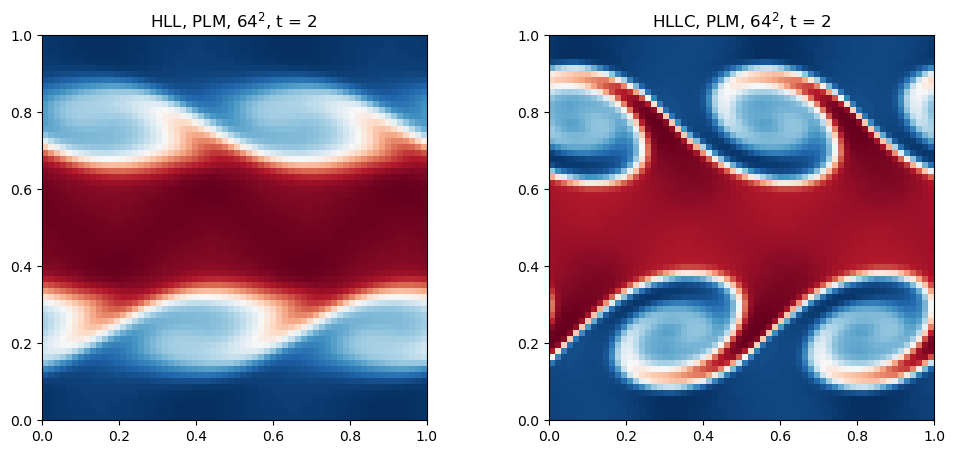

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, s in zip(axes, ['HLL', 'HLLC']):
    grid, state, par, eos, solver = setup("KHI2D", 64, 64, rec_type='PLM', RK_order='RK2', solver_type=s)
    state = evolve(solver, par, t_end=2.0)
    im = show(grid, interior(grid, state.dens), ax, f'{s}, PLM, $64^2$, t = 2', cmap='RdBu_r')
plt.show()

With HLL the numerical diffusion at the contacts is larger: the shear layers are thicker and the
rolled-up billows are more diffuse, with much less internal structure, and the vortices end up at
different positions. On a coarse grid the choice of the Riemann solver changes the details of the
nonlinear evolution, not just the sharpness of the picture.

**Rayleigh–Taylor instability.** A heavy fluid on top of a light one in a gravitational field is
unstable; in the linear regime a mode of wavenumber $k$ grows at the rate $\sqrt{A g k}$, with the
Atwood number $A = (\rho_h - \rho_l)/(\rho_h + \rho_l)$. The problem `RTI2D` seeds one mode, which grows
into the familiar rising bubbles and falling spikes that later roll up by the Kelvin–Helmholtz
instability. Gravity enters as a source term in the momentum and energy equations.

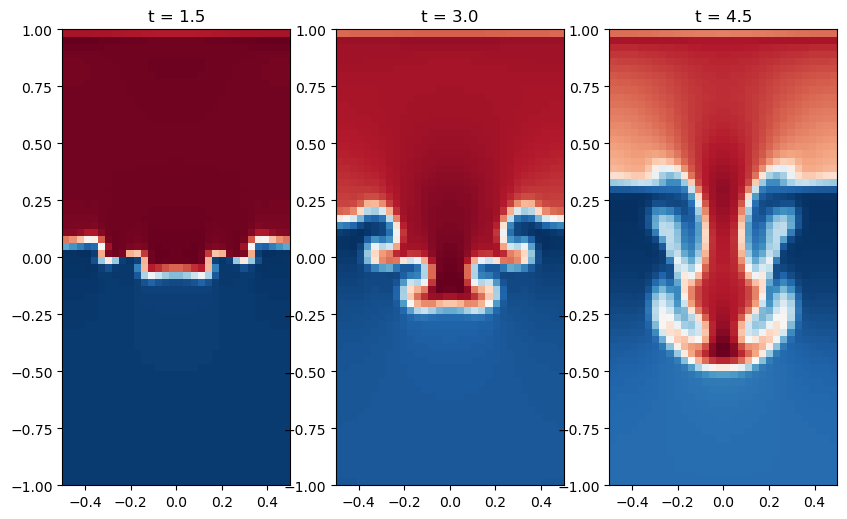

In [8]:
grid, state, par, eos, solver = setup("RTI2D", 32, 64, rec_type='PLM', RK_order='RK3', solver_type='HLLC')
fig, axes = plt.subplots(1, 3, figsize=(10, 6))
for ax, t in zip(axes, [1.5, 3.0, 4.5]):
    state = evolve(solver, par, t_end=t)
    show(grid, interior(grid, state.dens), ax, f't = {t}', cmap='RdBu_r')
plt.show()

Note the small bumps along the interface at $t = 1.5$. The seeded displacement of the interface is
represented on the grid as a staircase, which itself contains short-wavelength perturbations; since the
growth rate increases with $k$, they grow faster than the seeded mode until they saturate. Without
physical viscosity or surface tension the shortest resolved wavelengths are the most unstable, so
the small-scale structure of Rayleigh–Taylor fingers depends on the resolution.

**Low Mach number flows: the Gresho vortex.** The Gresho vortex is a steady rotating flow whose
centrifugal force is balanced by a pressure gradient; it should not change at all. Upwind schemes
add a dissipation proportional to the wave speeds $|u| + c$. At low Mach number the sound speed is much
larger than the flow velocity, and this dissipation, which is needed to stabilize the acoustic waves,
acts on the slow vortical flow as well. We measure how much kinetic energy the vortex keeps:

solver  kinetic energy at t = 1 relative to t = 0 (PPM, 32^2)
LLF     0.952
HLL     0.956
HLLC    0.984
Roe     0.984


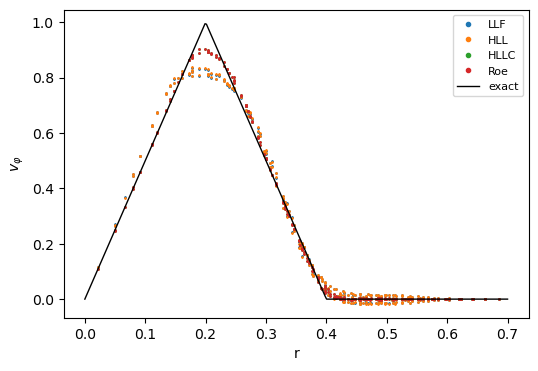

In [12]:
fig, ax = plt.subplots(figsize=(6, 4))
print(f"{'solver':6s}  kinetic energy at t = 1 relative to t = 0 (PPM, 32^2)")
for s in ['LLF', 'HLL', 'HLLC', 'Roe']:
    grid, state, par, eos, solver = setup("gresho2D", 32, 32, rec_type='PPM', RK_order='RK3', solver_type=s)
    ekin0 = np.sum(interior(grid, state.dens) * (interior(grid, state.vel1)**2 + interior(grid, state.vel2)**2))
    state = evolve(solver, par, t_end=1.0)
    rho, u, v = interior(grid, state.dens), interior(grid, state.vel1), interior(grid, state.vel2)
    print(f"{s:6s}  {np.sum(rho * (u**2 + v**2)) / ekin0:.3f}")
    x, y = interior(grid, grid.cx1) - 0.5, interior(grid, grid.cx2) - 0.5
    r = np.sqrt(x**2 + y**2)
    ax.plot(r.ravel(), ((x * v - y * u) / np.maximum(r, 1e-12)).ravel(), '.', ms=1, label=s)
rr = np.linspace(0, 0.7, 300)
ax.plot(rr, np.where(rr < 0.2, 5 * rr, np.where(rr < 0.4, 2 - 5 * rr, 0.0)), 'k-', lw=1, label='exact')
ax.set_xlabel('r'); ax.set_ylabel(r'$v_\varphi$'); ax.legend(fontsize=8, markerscale=6)
plt.show()

LLF and HLL, whose dissipation is set by the acoustic wave speeds, damp the vortex most and flatten
its peak; the solvers that resolve the contact and shear waves (HLLC and Roe, whose points practically
coincide) keep it best. Low-Mach-number flows — convection in stars, slow flows in disks — are a hard
case for compressible codes for exactly this reason, and special low-Mach variants of the Riemann
solvers exist.

## 5. Curvilinear geometry

Axisymmetric and disk problems are best computed on grids that follow their symmetry. Piastra offers
three curvilinear grids besides the Cartesian one:

| grid | coordinates | typical use |
|---|---|---|
| cylindrical | $(R, z)$, axisymmetric | jets, rotating stars, tori |
| polar | $(R, \varphi)$, in the plane | disks seen face-on |
| spherical | $(r, \theta)$, axisymmetric | explosions, winds, accretion |

The finite-volume update keeps its form, with exact cell volumes and face areas,

$$\frac{d\bar U_i}{dt} = -\frac{1}{V_i}\sum_{\rm faces} F_f A_f + S^{\rm geom}_i ,$$

but the momentum equations acquire **geometric source terms**, because the unit vectors change
direction from cell to cell. In cylindrical $(R, z)$ coordinates the radial momentum gains
$(p + \rho v_\varphi^2)/R$ and the azimuthal momentum $-\rho v_R v_\varphi / R$ (the Coriolis-like
term that conserves angular momentum); in polar $(R, \varphi)$ coordinates the same terms appear with
$v_\varphi$ an in-plane component; in spherical $(r, \theta)$ coordinates the radial momentum gains
$\big(2p + \rho(v_\theta^2 + v_\varphi^2)\big)/r$ and the $\theta$-momentum
$\big((p + \rho v_\varphi^2)\cot\theta - \rho v_r v_\theta\big)/r$. As shown in the previous notebook,
the pressure parts of these terms must be discretized consistently with the face areas, otherwise a gas
at rest does not stay at rest.

Two further features are specific to curvilinear grids.

* **The coordinate axis.** At $R = 0$ (or $\theta = 0, \pi$) the face area vanishes, so no flux
  crosses it; the ghost cells behind the axis are filled by reflection with the normal and azimuthal
  velocities reversed (boundary type `'axis'`).
* **Small cells.** On a polar grid the azimuthal width of the innermost cells, $R\,\Delta\varphi$, is
  tiny, and the CFL condition is set by them (in the test below the time step is about fifteen times
  smaller than on a Cartesian grid with the same spacing). This is the price of a grid that follows the geometry;
  production codes avoid it by excising the centre or by coarsening the innermost rings.

**Test 1: a planar shock tube on a polar grid.** The problem `sod2Dpol` places the Sod discontinuity
along the line $x = 0$ on a polar disk of radius 0.5. The solution is planar, $\rho(x, t)$, although the
grid is not; every cell should lie on the one-dimensional exact solution when plotted against
$x = R\cos\varphi$.

first time step on the polar grid: 1.95e-04; a Cartesian grid with the same spacing would allow about 3.0e-03


C:\Users\mrkon\AppData\Local\Temp\ipykernel_15760\3181019971.py:17: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im = axes[0].pcolormesh(x_cell, y_cell, rho, shading='auto', cmap='viridis')


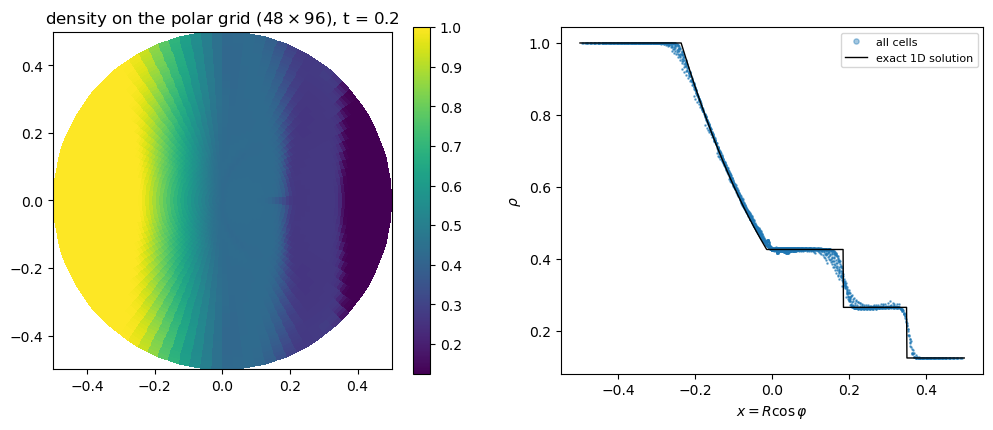

In [13]:
grid, state, par, eos, solver = setup("sod2Dpol", 48, 96, rec_type='PLM', RK_order='RK2', solver_type='HLLC')
with contextlib.redirect_stdout(io.StringIO()):
    solver.step_RK()                                    # one step, to read the time step
dt_polar = par.timenow
dx = 0.5 / 48
print(f"first time step on the polar grid: {dt_polar:.2e}; a Cartesian grid with the same spacing "
      f"would allow about {0.7 / (2 * 1.2 / dx):.1e}")
state = evolve(solver, par, t_end=0.2)

R, phi = interior(grid, grid.cx1), interior(grid, grid.cx2)
x_cell, y_cell = R * np.cos(phi), R * np.sin(phi)
rho = interior(grid, state.dens)
xe = np.linspace(-0.5, 0.5, 1000)
rho_e = exact_riemann_solution(1.0, 0.0, 1.0, 0.125, 0.0, 0.1, eos.GAMMA, xe, par.timenow, x0=0.0)[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
im = axes[0].pcolormesh(x_cell, y_cell, rho, shading='auto', cmap='viridis')
axes[0].set_aspect('equal'); axes[0].set_title(r'density on the polar grid ($48 \times 96$), t = 0.2')
plt.colorbar(im, ax=axes[0])
axes[1].plot(x_cell.ravel(), rho.ravel(), '.', ms=1.5, alpha=0.4, label='all cells')
axes[1].plot(xe, rho_e, 'k-', lw=1, label='exact 1D solution')
axes[1].set_xlabel(r'$x = R\cos\varphi$'); axes[1].set_ylabel(r'$\rho$'); axes[1].legend(fontsize=8, markerscale=5)
plt.show()

The cells collapse onto the one-dimensional solution, with a spread that comes from the different
resolution in different parts of the disk: fine in azimuth near the centre, coarse at the rim. The waves
cross the grid lines at all angles, which makes this a good test of the metric terms: an error in the
geometric sources would show up as a systematic difference between cells at different $\varphi$ with the
same $x$.

**Test 2: a spherical blast wave in cylindrical coordinates.** The Sedov–Taylor problem `sedov2Dcyl`
deposits the energy $E = 1$ (for the full sphere) at the origin of an $(R, z)$ grid. The blast wave is
spherical, so its structure must depend only on $r = \sqrt{R^2 + z^2}$, even though the grid is
cylindrical; and its radius follows the self-similar law
$r_{\rm sh} = \xi_0\,(E t^2/\rho)^{1/5}$ with $\xi_0 \approx 1.03$ for $\gamma = 1.4$.

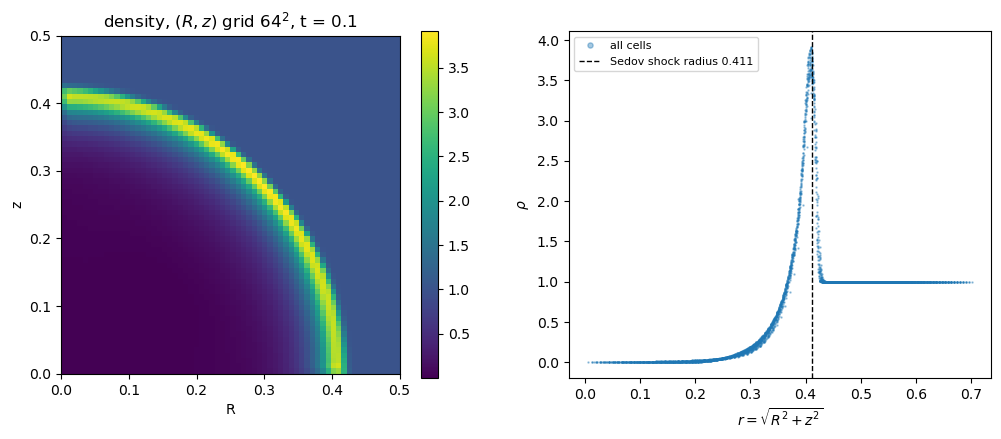

radius of the density peak: 0.409, Sedov: 0.411


In [14]:
grid, state, par, eos, solver = setup("sedov2Dcyl", 64, 64, rec_type='PLM', RK_order='RK2', solver_type='HLLC')
state = evolve(solver, par, t_end=0.1)
R, z = interior(grid, grid.cx1), interior(grid, grid.cx2)
rho = interior(grid, state.dens)
r = np.sqrt(R**2 + z**2)
r_shock_sedov = 1.033 * (1.0 * par.timenow**2 / 1.0)**0.2

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
im = axes[0].pcolormesh(R, z, rho, shading='auto', cmap='viridis')
axes[0].set_aspect('equal'); axes[0].set_xlabel('R'); axes[0].set_ylabel('z')
axes[0].set_title(r'density, $(R, z)$ grid $64^2$, t = 0.1')
plt.colorbar(im, ax=axes[0])
axes[1].plot(r.ravel(), rho.ravel(), '.', ms=1.5, alpha=0.4, label='all cells')
axes[1].axvline(r_shock_sedov, color='k', ls='--', lw=1, label=f'Sedov shock radius {r_shock_sedov:.3f}')
axes[1].set_xlabel(r'$r = \sqrt{R^2 + z^2}$'); axes[1].set_ylabel(r'$\rho$'); axes[1].legend(fontsize=8, markerscale=5)
plt.show()
i_peak = np.argmax(rho)
print(f"radius of the density peak: {r.ravel()[i_peak]:.3f}, Sedov: {r_shock_sedov:.3f}")

The cells collapse onto a single radial profile, and the shock sits at the self-similar radius.
The peak density behind the shock stays below the strong-shock limit $(\gamma+1)/(\gamma-1) = 6$ at
this resolution: the thin post-shock shell of a Sedov blast is, like the shell of the strong shock tube
in the previous notebook, only a few cells wide.

## Summary

* The multidimensional update combines one-dimensional Riemann problems at the face centres; the CFL
  condition sums the signal speeds over the directions.
* The midpoint evaluation of the face flux limits the scheme to second order for smooth 2D flows,
  whatever the reconstruction; high-order reconstructions still pay off through smaller errors.
* Circular fronts on Cartesian grids carry a grid imprint; curvilinear grids avoid it for problems with
  the matching symmetry, at the price of geometric source terms, a coordinate axis, and small cells.
* The Riemann solver can change the physical outcome of unstable flows (KHI), and the dissipation of
  upwind schemes is a problem at low Mach number (Gresho vortex).

## Exercises

1. Repeat the vortex test with PPM, and with RK2 instead of RK3. Which error dominates at $160^2$?
2. Run `sod2Dcart` at $64^2$, $128^2$, and $256^2$ and measure how the spread of the cloud of points
   around the radial reference decreases.
3. Compare the Kelvin–Helmholtz runs at $256^2$ with PLM and with MP5. At which resolution do the
   HLL and HLLC runs start to look alike?
4. Lower the Mach number of the Gresho vortex by raising the background pressure in the initial
   conditions. How does the kinetic energy loss of LLF and HLLC change?
5. Run the Sedov problem on the Cartesian grid (`sedov2Dcart`, a cylindrical blast) and check the
   self-similar law $r_{\rm sh} \propto t^{1/2}$ for the cylindrical case.
6. On the polar grid, replace the radial cell centres by the arithmetic midpoints (as in the previous
   notebook) and repeat Test 1. Where do the errors appear?